# BetaGDD — PEP725 Apple: Profile Loss per Cultivar

Runs α and β profile loss separately on the early and late apple cultivars.
Motivation: the combined profile for α was all noise, likely because two cultivars
with different true α values are mixed into a single global model.
If per-cultivar profiles are cleaner, it supports using a contextual model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm.auto import tqdm

from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.models.beta_gdd import GlobalBetaGDDModel

OBS_KEY = 'BBCH_60'
CUTOFF  = 2010
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'

SUBGROUP_EARLY = ('pep725', 220, 100)
SUBGROUP_LATE  = ('pep725', 220, 130)

print('Device:', DEVICE)

Device: cuda


## 1. Load data

In [2]:
cal    = Calendar(default_start='10-01', default_length=365)
_cache = FeatureCache.load(FeatureCache.default_path('PEP725_Apple', ['temperature_2m_mean']))
ds_all = Dataset.load('PEP725_Apple', calendar=cal, feature_providers=[_cache])

ds_early = ds_all.select_species([SUBGROUP_EARLY])
ds_late  = ds_all.select_species([SUBGROUP_LATE])

target_fn = lambda s: s['observations'][OBS_KEY]

def trn_tst(ds):
    years = sorted(ds.years)
    return (ds.select_years([y for y in years if y < CUTOFF]),
            ds.select_years([y for y in years if y >= CUTOFF]))

ds_early_trn, ds_early_tst = trn_tst(ds_early)
ds_late_trn,  ds_late_tst  = trn_tst(ds_late)

for name, trn, tst in [('Early', ds_early_trn, ds_early_tst),
                        ('Late',  ds_late_trn,  ds_late_tst)]:
    print(f'{name}  train={len(trn)}  test={len(tst)}')

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 42388.85it/s]


Early  train=3956  test=1107
Late  train=1193  test=340


## 2. Train GlobalBetaGDDModel per cultivar

In [3]:
FIT_KWARGS = dict(
    target_fn        = target_fn,
    model_kwargs     = dict(
        t_low            = 1.4,
        t_high           = 15.9,
        learn_bounds     = False,
        alpha_init       = 2.0,
        beta_init        = 2.0,
        learn_alpha_beta = True,
        learn_t_base     = False,
        t_base_init      = 5.0,
        learn_thresholds = True,
    ),
    num_epochs               = 1000,
    batch_size               = 512,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-4,
    device  = DEVICE,
    verbose = True,
)

model_early, _ = GlobalBetaGDDModel.fit(dataset=ds_early_trn, **FIT_KWARGS)
model_late,  _ = GlobalBetaGDDModel.fit(dataset=ds_late_trn,  **FIT_KWARGS)

for name, m in [('Early', model_early), ('Late', model_late)]:
    α, β = m.alpha.item(), m.beta.item()
    print(f'{name}  α={α:.3f}  β={β:.3f}')

GlobalBetaGDDModel epoch [    1/1000] lr=1.00e-03 loss=1.83883: 100%|██████████| 7/7 [00:00<00:00, 30.01it/s]
GlobalBetaGDDModel epoch [    2/1000] lr=1.00e-03 loss=1.35152: 100%|██████████| 7/7 [00:00<00:00, 129.70it/s]
GlobalBetaGDDModel epoch [    3/1000] lr=1.00e-03 loss=1.30676: 100%|██████████| 7/7 [00:00<00:00, 130.81it/s]
GlobalBetaGDDModel epoch [    4/1000] lr=1.00e-03 loss=1.13954: 100%|██████████| 7/7 [00:00<00:00, 125.48it/s]
GlobalBetaGDDModel epoch [    5/1000] lr=1.00e-03 loss=1.04189: 100%|██████████| 7/7 [00:00<00:00, 120.21it/s]
GlobalBetaGDDModel epoch [    6/1000] lr=1.00e-03 loss=0.94339: 100%|██████████| 7/7 [00:00<00:00, 133.34it/s]
GlobalBetaGDDModel epoch [    7/1000] lr=1.00e-03 loss=0.93495: 100%|██████████| 7/7 [00:00<00:00, 134.99it/s]
GlobalBetaGDDModel epoch [    8/1000] lr=1.00e-03 loss=0.86133: 100%|██████████| 7/7 [00:00<00:00, 134.86it/s]
GlobalBetaGDDModel epoch [    9/1000] lr=1.00e-03 loss=0.78366: 100%|██████████| 7/7 [00:00<00:00, 136.01it/s]
Gl

Early  α=1.853  β=2.137
Late  α=1.855  β=2.546


## 3. Profile loss over α and β

In [4]:
def _best_val_loss(fit_info):
    vals = [e['val']['loss'] for e in fit_info['epochs'] if 'val' in e]
    return min(vals) if vals else fit_info['epochs'][-1]['loss']

def profile_over(param, grid, ds, t_fn, device, num_epochs=500, patience=5):
    assert param in ('alpha', 'beta')
    losses = []
    for val in tqdm(grid, desc=f'Profile {param}'):
        m = GlobalBetaGDDModel(
            alpha_init=float(val) if param == 'alpha' else 2.0,
            beta_init =float(val) if param == 'beta'  else 2.0,
            learn_alpha_beta=True,
            t_low=1.4, t_high=15.9, learn_bounds=False,
            learn_t_base=False, t_base_init=5.0, learn_thresholds=True,
        ).to(device)
        if param == 'alpha':
            m._raw_alpha.requires_grad_(False)
        else:
            m._raw_beta.requires_grad_(False)
        _, fi = GlobalBetaGDDModel.fit(
            target_fn=t_fn, dataset=ds, model=m,
            num_epochs=num_epochs, batch_size=512, val_period=5,
            optimizer='adam', optimizer_kwargs=dict(lr=1e-3, weight_decay=1e-4),
            early_stopping=True, early_stopping_patience=patience,
            early_stopping_min_delta=1e-4, device=device, verbose=False,
        )
        losses.append(_best_val_loss(fi))
    return losses

GRID = np.linspace(1.1, 6.0, 25)

print('--- Early cultivar ---')
early_alpha_losses = profile_over('alpha', GRID, ds_early_trn, target_fn, DEVICE)
early_beta_losses  = profile_over('beta',  GRID, ds_early_trn, target_fn, DEVICE)

print('--- Late cultivar ---')
late_alpha_losses = profile_over('alpha', GRID, ds_late_trn, target_fn, DEVICE)
late_beta_losses  = profile_over('beta',  GRID, ds_late_trn, target_fn, DEVICE)

--- Early cultivar ---


Profile alpha:   0%|          | 0/25 [00:00<?, ?it/s]

Profile beta:   0%|          | 0/25 [00:00<?, ?it/s]

--- Late cultivar ---


Profile alpha:   0%|          | 0/25 [00:00<?, ?it/s]

Profile beta:   0%|          | 0/25 [00:00<?, ?it/s]

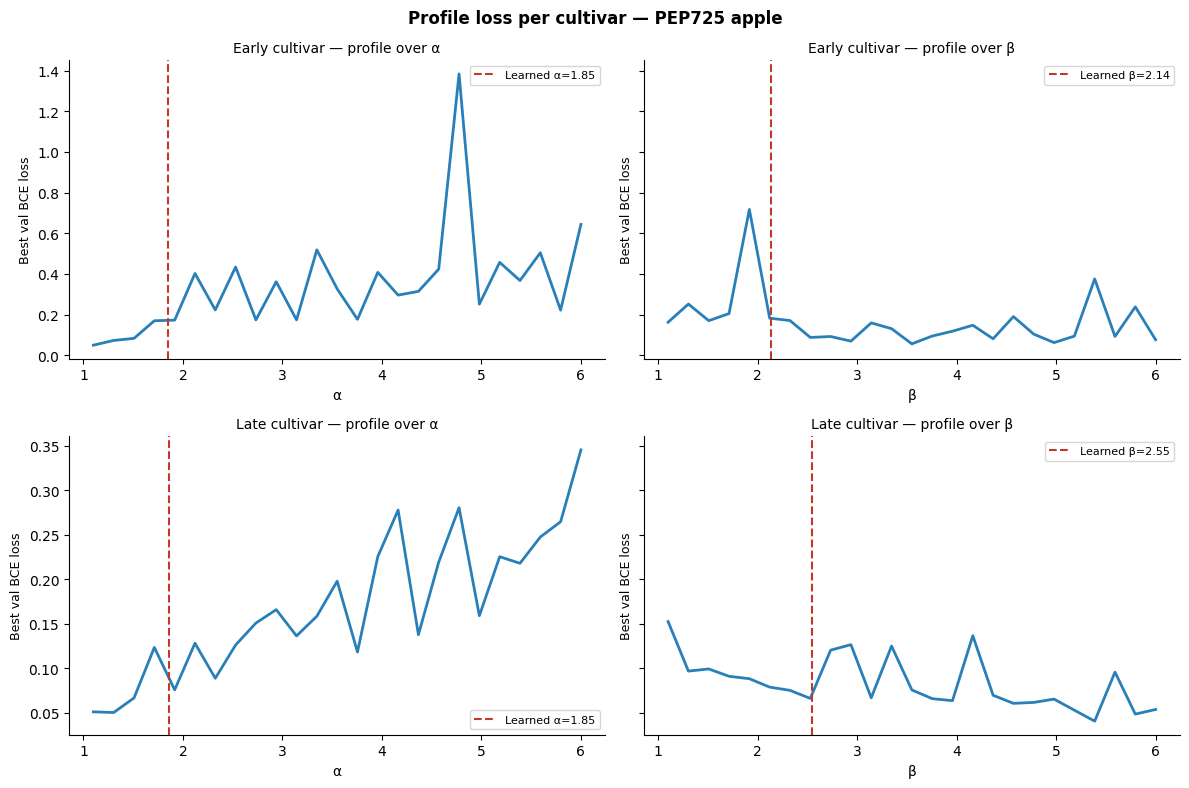

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')
fig.suptitle('Profile loss per cultivar — PEP725 apple', fontsize=12, fontweight='bold')

configs = [
    (axes[0, 0], early_alpha_losses, 'α', model_early.alpha.item(), 'Early cultivar'),
    (axes[0, 1], early_beta_losses,  'β', model_early.beta.item(),  'Early cultivar'),
    (axes[1, 0], late_alpha_losses,  'α', model_late.alpha.item(),  'Late cultivar'),
    (axes[1, 1], late_beta_losses,   'β', model_late.beta.item(),   'Late cultivar'),
]

for ax, losses, param, learned_val, cultivar in configs:
    ax.plot(GRID, losses, color='#2980b9', lw=2)
    ax.axvline(learned_val, color='#c0392b', lw=1.5, ls='--',
               label=f'Learned {param}={learned_val:.2f}')
    ax.set_xlabel(param, fontsize=10)
    ax.set_ylabel('Best val BCE loss', fontsize=9)
    ax.set_title(f'{cultivar} — profile over {param}', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Quantitative identifiability metrics

In [6]:
def identifiability_metrics(grid, losses, delta=0.005):
    grid   = np.asarray(grid,   dtype=float)
    losses = np.asarray(losses, dtype=float)
    i_min    = np.argmin(losses)
    min_loss = losses[i_min]
    argmin   = grid[i_min]
    if 0 < i_min < len(grid) - 1:
        h  = grid[i_min + 1] - grid[i_min - 1]
        d2 = (losses[i_min + 1] - 2 * losses[i_min] + losses[i_min - 1]) / (h / 2) ** 2
    else:
        d2 = float('nan')
    in_ci = losses <= min_loss + delta
    lo, hi = i_min, i_min
    while lo > 0 and in_ci[lo - 1]:
        lo -= 1
    while hi < len(grid) - 1 and in_ci[hi + 1]:
        hi += 1
    return dict(argmin=argmin, min_loss=min_loss, curvature=d2,
                ci_lo=grid[lo], ci_hi=grid[hi], ci_width=grid[hi] - grid[lo])


DELTA = 0.005

rows = {}
for label, losses_arr in [
    ('early_α', early_alpha_losses), ('early_β', early_beta_losses),
    ('late_α',  late_alpha_losses),  ('late_β',  late_beta_losses),
]:
    rows[label] = identifiability_metrics(GRID, losses_arr, delta=DELTA)

df = pd.DataFrame(rows).T[['argmin', 'min_loss', 'curvature', 'ci_lo', 'ci_hi', 'ci_width']].round(4)
df.index.name = 'param'
print(f'Profile identifiability metrics  (δ={DELTA})')
print(df.to_string())

Profile identifiability metrics  (δ=0.005)
         argmin  min_loss  curvature   ci_lo   ci_hi  ci_width
param                                                         
early_α  1.1000    0.0494        NaN  1.1000  1.1000    0.0000
early_β  3.5500    0.0559     2.7101  3.5500  3.5500    0.0000
late_α   1.3042    0.0502     0.4114  1.1000  1.3042    0.2042
late_β   5.3875    0.0405     1.6173  5.3875  5.3875    0.0000
